In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# 剩下所有业务代码

In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ---------- 数据准备 ----------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST('./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST('./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

# ---------- 模型定义 ----------
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),           # [B, 1, 28, 28] → [B, 784]
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),     # 输出10个类别
        )

    def forward(self, x):
        return self.net(x)

# ---------- 训练配置 ----------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MNISTNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ---------- 训练循环 ----------
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    acc = correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {avg_loss:.4f}  Train Acc: {acc:.2%}")

Epoch [1/10]  Loss: 0.2250  Train Acc: 93.26%
Epoch [2/10]  Loss: 0.0910  Train Acc: 97.20%
Epoch [3/10]  Loss: 0.0639  Train Acc: 97.97%
Epoch [4/10]  Loss: 0.0496  Train Acc: 98.39%
Epoch [5/10]  Loss: 0.0396  Train Acc: 98.62%
Epoch [6/10]  Loss: 0.0338  Train Acc: 98.86%
Epoch [7/10]  Loss: 0.0291  Train Acc: 99.07%
Epoch [8/10]  Loss: 0.0253  Train Acc: 99.12%
Epoch [9/10]  Loss: 0.0214  Train Acc: 99.29%
Epoch [10/10]  Loss: 0.0205  Train Acc: 99.33%


In [3]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        preds = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

In [4]:
print(f"测试集准确率: {correct / total:.2%}")

测试集准确率: 97.68%


In [5]:
images, labels = next(iter(test_loader))

with torch.no_grad():
    images, labels = images.to(device), labels.to(device)

    preds = model(images).argmax(dim=1)

In [6]:
images

tensor([[[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.424

In [7]:
preds

tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2,
        4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3, 7, 4, 6, 4, 3, 0, 7, 0,
        2, 9, 1, 7, 3, 2, 9, 7, 7, 6, 2, 7, 8, 4, 7, 3, 6, 1, 3, 6, 4, 3, 1, 4,
        1, 7, 6, 9, 6, 0, 5, 4, 9, 9, 2, 1, 9, 4, 8, 7, 3, 9, 7, 4, 4, 4, 9, 2,
        5, 4, 7, 6, 7, 9, 0, 5, 8, 5, 6, 6, 5, 7, 8, 1, 0, 1, 6, 4, 6, 7, 3, 1,
        7, 1, 8, 2, 0, 2, 9, 9, 5, 5, 1, 5, 6, 0, 2, 4, 4, 6, 5, 4, 6, 5, 4, 5,
        1, 4, 4, 7, 2, 3, 2, 7, 1, 8, 1, 8, 1, 8, 5, 0, 8, 9, 2, 5, 0, 1, 1, 1,
        0, 9, 0, 3, 1, 6, 4, 2, 3, 6, 1, 1, 1, 3, 9, 5, 2, 9, 4, 5, 9, 3, 9, 0,
        3, 6, 5, 5, 7, 2, 2, 7, 1, 2, 8, 4, 1, 7, 3, 3, 8, 8, 7, 9, 2, 2, 4, 1,
        5, 9, 8, 7, 2, 3, 0, 2, 4, 2, 4, 1, 9, 5, 7, 7], device='cuda:0')

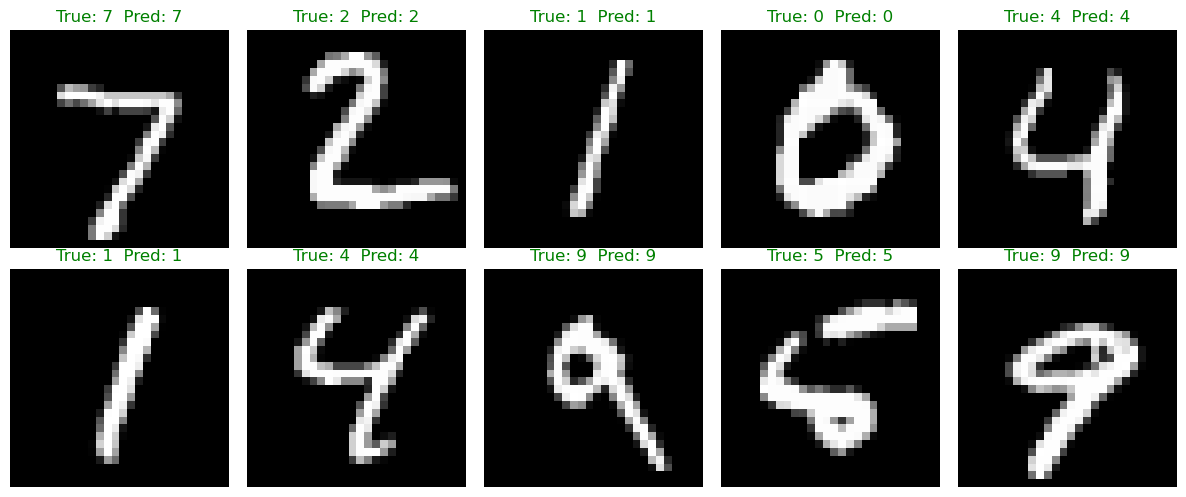

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().cpu().numpy()

    true_label = labels[i].item()
    pred_label = preds[i].item()

    ax.imshow(img, cmap='gray')

    color = 'green' if true_label == pred_label else 'red'

    ax.set_title(f"True: {true_label}  Pred: {pred_label}", color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig('mnist_predictions.png', dpi=100)
plt.show()

In [15]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        out = model(images)
        preds = out.argmax(dim=1)
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

# 先校验长度是否一致，方便调试
print(f"样本总数: labels={len(all_labels)}, preds={len(all_preds)}")

for digit in range(10):
    idx = [i for i, l in enumerate(all_labels) if l == digit]
    if len(idx) == 0:
        print(f"数字 {digit}: 无测试样本")
        continue
    digit_correct = sum(1 for i in idx if all_preds[i] == digit)
    acc = digit_correct / len(idx)
    print(f"数字 {digit}: {digit_correct}/{len(idx)} = {acc:.2%}")

样本总数: labels=10000, preds=10000
数字 0: 969/980 = 98.88%
数字 1: 1124/1135 = 99.03%
数字 2: 1013/1032 = 98.16%
数字 3: 981/1010 = 97.13%
数字 4: 970/982 = 98.78%
数字 5: 864/892 = 96.86%
数字 6: 941/958 = 98.23%
数字 7: 992/1028 = 96.50%
数字 8: 940/974 = 96.51%
数字 9: 974/1009 = 96.53%
